#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

## Optimized Layouts

### WInd Rose

In [2]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


### Floris Interface

In [3]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [4]:
def aep_powers(fi, df):
    power_list = []
    fi.reinitialize(
        layout_x=df["Layout_x"],
        layout_y=df['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

#### Defining Populations

#### Defining Parameters

In [5]:
min_distance = 126
tournament_size = 3
target_coverage_area = 800000
turbine_diameter = 52
mutation_rate = 0.8
crossover_rate = 0.7
population_size = 100
generations = 100
elitism = True

max_distance = turbine_diameter * 5
min_distance = turbine_diameter
max_turbines = 65
min_turbines = 20

next_gen_population_size = 20

### The GA Implmentation

In [6]:
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
import scipy.spatial.distance
import random
import matplotlib.pyplot as plt

min_distance = 126
tournament_size = 3
target_coverage_area = 800000
turbine_diameter = 52
mutation_rate = 0.8
crossover_rate = 0.7
population_size = 100
generations = 100
elitism = True

max_distance = turbine_diameter * 5
min_turbines = 14
max_turbines = 17

next_gen_population_size = 2

def initialize_populations():
    populations = []
    for num_turbines in np.repeat(range(min_turbines, max_turbines), 4):  # Generate initial populations
        layout = pd.DataFrame(columns=['Layout_x', 'Layout_y'])
        layout.loc[0] = [0, 0]  # Set the first turbine at the origin
        for _ in range(1, num_turbines):
            while True:
                new_turbine = pd.DataFrame(np.random.uniform(turbine_diameter, max_distance, size=(1, 2)), columns=['Layout_x', 'Layout_y'])
                if all(np.linalg.norm(layout[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= turbine_diameter):
                    temp_df = pd.concat([layout, new_turbine], ignore_index=True)
                    layout = temp_df.copy()  # Assign the concatenated DataFrame back to layout
                    break
        populations.append(layout)
    return populations

def calculate_fitness(layout):
    num_turbines = len(layout)
    if num_turbines == 1:
        return 1  # Avoid division by zero
    distances = scipy.spatial.distance.pdist(layout[['Layout_x', 'Layout_y']].values)
    wake_effect = np.sum(1 / distances)
    return num_turbines - wake_effect

def tournament_selection(populations):
    tournament = random.sample(populations, tournament_size)
    return max(tournament, key=calculate_fitness)

def crossover(parent1, parent2):
    min_length = min(len(parent1), len(parent2))
    child = parent1.copy()

    for column in child.columns:
        random_mask = np.random.rand(min_length) < 0.5
        child_vals = np.where(random_mask, parent1[column][:min_length], parent2[column][:min_length])
        child[column][:min_length] = child_vals

    return child

def mutate(df):
    if np.random.rand() < mutation_rate:
        if min_turbines < len(df) < max_turbines:  # Ensure the number of turbines stays within range
            if len(df) > min_turbines:
                df = df.drop(np.random.choice(df.index[1:]))  # Do not remove the turbine at the origin
            else:
                new_turbine = pd.DataFrame(np.random.uniform(turbine_diameter, max_distance, size=(1, 2)), columns=['Layout_x', 'Layout_y'])
                if all(np.linalg.norm(df[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= turbine_diameter):
                    df = df.append(new_turbine, ignore_index=True)
    return df

def calculate_enclosed_area(layout):
    points = layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    return hull.volume

def run_genetic_algorithm(populations):
    best_layouts = {i: None for i in range(min_turbines, max_turbines)}  # Initialize a dictionary to store the best layout for each number of turbines

    for _ in range(next_gen_population_size):
        next_gen = []
        for _ in range(len(populations)):
            parent1 = tournament_selection(populations)
            parent2 = tournament_selection(populations)
            child = crossover(parent1, parent2)
            child = mutate(child)
            next_gen.append(child)
        populations = next_gen

    # Sort populations by fitness and enclosed area
    populations.sort(key=lambda p: (calculate_fitness(p), -calculate_enclosed_area(p)), reverse=True)

    # Update best_layouts with the best layout for each number of turbines
    for population in populations:
        num_turbines = len(population)
        if min_turbines <= num_turbines <= (max_turbines - 1) and best_layouts[num_turbines] is None and calculate_enclosed_area(population) <= target_coverage_area:
            best_layouts[num_turbines] = population

    # If all layouts exceed 800,000 sq meters, return the one with the smallest area
    for num_turbines in range(min_turbines, max_turbines):
        if best_layouts[num_turbines] is None:
            best_layouts[num_turbines] = min(populations, key=calculate_enclosed_area)

    # Return a layout with a random number of turbines from 3 to 8
    return best_layouts[np.random.choice(range(min_turbines, max_turbines))]

def plot_best_layout(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)
    # ax.set_title('Best Layout')
    plt.tight_layout()
    plt.show()

def main():
    populations = initialize_populations()
    best_layout = run_genetic_algorithm(populations)  # Get only the best layout

    plot_best_layout(best_layout)  # Plot only the best layout
    print(best_layout)
    print("Enclosed area: ", calculate_enclosed_area(best_layout))

if __name__ == "__main__":
    main()


In [ ]:
def plot_best_layouts(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)

    # Calculate and plot Convex Hull
    points = best_layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], 'k-')

    # Shade the area enclosed by the Convex Hull
    ax.fill(points[hull.vertices,0], points[hull.vertices,1], 'k', alpha=0.3)

In [ ]:
populations = initialize_populations()
best_layout = run_genetic_algorithm(populations)  # Get only the best layout
plot_best_layout(best_layout)  # Plot only the best layout
plot_best_layouts(best_layout)
print(calculate_enclosed_area(best_layout))
len(best_layout)

def get_gen1_populations():
    gen_1_pop = []
    for _ in range(40):
        best_layout = run_genetic_algorithm(populations)
        gen_1_pop.append(best_layout)
    return gen_1_pop

gen_1_pop = get_gen1_populations()
gen_1_pop[0]

In [ ]:
# def find_ct(c_p):
#     ct = c_p  # Initial guess
#     epsilon = 1e-6  # Tolerance for convergence

#     while True:
#         new_ct = (ct + ct * (1 - ct)**0.5) / 2
#         if abs(new_ct - ct) < epsilon:
#             break
#         ct = new_ct

#     return ct

# # Find Ct for Cp = 0.1, 0.3, 0.41
# cp_values = [0.1, 0.3, 0.41]

# for cp in cp_values:
#     ct_result = find_ct(cp)
#     print(f"For Cp = {cp}, Ct = {ct_result}")


For Cp = 0.1, Ct = 0.0019991246953920644
For Cp = 0.3, Ct = 0.0019994778117358343
For Cp = 0.41, Ct = 0.0019993562838778456


  ### Floris Initailization

In [ ]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [ ]:
def powers(fi, gen_1_pop):
    power_list = []
    fi.reinitialize(
        layout_x=gen_1_pop["Layout_x"],
        layout_y=gen_1_pop['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list


# nrel_p1_powers[]
# populations = initialize_populations()
gen_1_pop = get_gen1_populations()

for _ in range(len(gen_1_pop)):
    nrel_p1_powers = powers(fi_nrel, gen_1_pop[_])
    print(nrel_p1_powers)

# for _ in range(len(populations)):
#     nrel_p1_powers = powers(fi_nrel, populations[_])
#     print(nrel_p1_powers)
# nrel_p1_powers = powers(fi_nrel, gen_1_pop[0])
# nrel_p1_powers

/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

[68.146, 86.978, 21.651]
[60.951, 86.978, 29.923]
[68.003, 86.978, 21.816]
[62.581, 86.978, 28.049]
[65.284, 86.978, 24.942]
[65.46, 86.978, 24.739]
[63.949, 86.978, 26.476]
[65.32, 86.978, 24.901]
[60.053, 86.978, 30.956]
[65.321, 86.978, 24.9]
[59.689, 86.978, 31.375]
[66.739, 99.403, 32.86]
[58.552, 86.978, 32.681]
[64.768, 86.978, 25.535]
[64.405, 86.978, 25.953]
[58.229, 86.978, 33.053]
[63.956, 74.552, 14.214]
[59.705, 86.978, 31.356]
[64.919, 86.978, 25.361]
[71.253, 99.403, 28.319]
[68.022, 99.403, 31.57]
[60.172, 86.978, 30.819]
[69.464, 99.403, 30.119]
[72.494, 99.403, 27.07]
[70.724, 99.403, 28.851]
[71.535, 99.403, 28.035]
[60.466, 99.403, 39.171]
[60.247, 86.978, 30.732]
[64.846, 86.978, 25.445]
[53.676, 74.552, 28.002]
[65.541, 86.978, 24.646]
[61.533, 86.978, 29.254]
[64.365, 86.978, 25.998]
[51.996, 74.552, 30.256]
[63.422, 86.978, 27.083]
[57.374, 74.552, 23.042]
[58.735, 86.978, 32.472]
[62.706, 86.978, 27.906]
[65.122, 86.978, 25.128]
[60.336, 86.978, 30.631]


In [ ]:


gen_2 = []
while len(gen_2) < 3:
    try:
        best_layout = run_genetic_algorithm(populations)
        nrel_p1_powers = powers(fi_nrel, best_layout)
        if nrel_p1_powers[2] < 20:
            gen_2.append(best_layout)
    except Exception as e:
        print(f"An error occurred: {e}")
        continue

len(gen_2)

/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


...

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

An error occurred: 'DataFrame' object has no attribute 'append'


/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake_effect = np.sum(1 / distances)
/tmp/ipykernel_3652/1982666131.py:20: RuntimeWarning: divide by zero encountered in divide
  wake

3

In [ ]:
print(powers(fi_nrel, gen_2[0]))
print(powers(fi_nrel, gen_2[1]))
print(powers(fi_nrel, gen_2[2]))

[62.255, 74.552, 16.495]
[60.634, 74.552, 18.669]
[60.228, 74.552, 19.213]


In [ ]:
# print(gen_2[0])
# print(gen_2[1])
# print(gen_2[2])

In [ ]:
populations.to_csv('populations_0.csv')

AttributeError: 'list' object has no attribute 'to_csv'

In [ ]:
gen_2[0].to_csv('v1.csv')
gen_2[1].to_csv('v2.csv')
gen_2[2].to_csv('v3.csv')

In [21]:
power_outputs = []
for layout in gen_1_pop:
    power_output = powers(fi_nrel, layout)
    power_outputs.append(power_output)

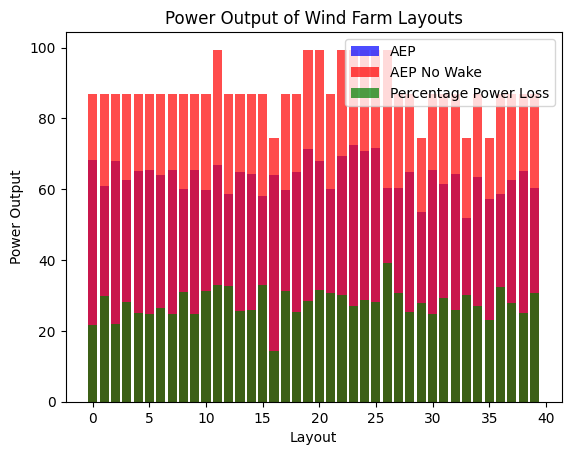

In [22]:
import matplotlib.pyplot as plt

# Assuming power_outputs is a list of lists, where each sublist is [aep, aep_no_wake, percentage_power_loss]
aep_values = [output[0] for output in power_outputs]
aep_no_wake_values = [output[1] for output in power_outputs]
percentage_power_loss_values = [output[2] for output in power_outputs]

# Create a new figure
plt.figure()

# Create a bar plot for aep values
plt.bar(range(len(aep_values)), aep_values, color='b', alpha=0.7, label='AEP')

# Create a bar plot for aep_no_wake values
plt.bar(range(len(aep_no_wake_values)), aep_no_wake_values, color='r', alpha=0.7, label='AEP No Wake')

# Create a bar plot for percentage_power_loss values
plt.bar(range(len(percentage_power_loss_values)), percentage_power_loss_values, color='g', alpha=0.7, label='Percentage Power Loss')

# Add labels and title
plt.xlabel('Layout')
plt.ylabel('Power Output')
plt.title('Power Output of Wind Farm Layouts')
plt.legend()

# Show the plot
plt.show()